# **Experience Reply for Continual Learning**

## **1. Import Libraries**

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## **2. Reproducibility**

In [32]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

Using device: cuda



## **3. Reply Buffer**

In [33]:
class ReplyBuffer:
  def __init__(self, max_size: int = 500):
    self.max_size = max_size
    self.xs: list = []
    self.ys: list = []

  # Add a batch of samples (random replacement when full)
  def add(self, x_batch: torch.Tensor, y_batch: torch.Tensor) -> None:
    for x, y in zip(x_batch.detach().cpu(), y_batch.detach().cpu()):
      if len(self.xs) < self.max_size:
        self.xs.append(x.clone())
        self.ys.append(y.clone())
      else:
        idx = random.randint(0, self.max_size - 1)
        self.xs[idx] = x.clone()
        self.ys[idx] = y.clone()

   # Randomly sample old examples from the buffer
  def sample(self, n_samples: int, device: torch.device):
    if len(self.xs) == 0:
      return None, None
    n = min(n_samples, len(self.xs))
    indices = random.sample(range(len(self.xs)), n)
    x_out = torch.stack([self.xs[i] for i in indices]).to(device)
    y_out = torch.stack([self.ys[i] for i in indices]).to(device)
    return x_out, y_out

  def store_task_samples(self, loader: DataLoader, n_samples: int) -> None:
    all_x, all_y = [], []
    for x_batch, y_batch in loader:
      all_x.append(x_batch)
      all_y.append(y_batch)
      if sum(t.size(0) for t in all_x) >= n_samples * 2:
        break

    all_x = torch.cat(all_x, dim=0)
    all_y = torch.cat(all_y, dim=0)
    perm = torch.randperm(len(all_x))[:n_samples]
    self.add(all_x[perm], all_y[perm])

  def __len__(self) -> int:
    return len(self.xs)

  def __repr__(self) -> str:
    return f"ReplyBuffer({len(self.xs)}/{self.max_size} samples)"


## **4. Neural Network**

In [34]:
class MLP(nn.Module):
  def __init__(self, input_dim: int = 784, hidden_dim: int = 256, output_dim: int = 10):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(hidden_dim, output_dim)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.net(x)

## **5. Dataset - Split-MNIST**

In [35]:
TASK_CLASSES = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]
N_TASKS = len(TASK_CLASSES)

def build_split_mnist(data_root: str = "./data", batch_size: int = 128):
  tf = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.1307,), (0.3081,))
  ])
  train_ds = torchvision.datasets.MNIST(data_root, train=True, download=True, transform=tf)
  test_ds = torchvision.datasets.MNIST(data_root, train=False, download=True, transform=tf)

  print(f"Split-MNIST - {N_TASKS} tasks")
  loaders = []
  for t, (c0, c1) in enumerate(TASK_CLASSES):
    tr_idx = [i for i, (_, y) in enumerate(train_ds) if y in (c0, c1)]
    te_idx = [i for i, (_, y) in enumerate(test_ds) if y in (c0, c1)]

    tr = DataLoader(Subset(train_ds, tr_idx), batch_size=batch_size, shuffle=True)
    te = DataLoader(Subset(test_ds, te_idx), batch_size=256, shuffle=False)

    print(f"  Task {t+1}: digits {c0}&{c1}  |  train={len(tr_idx):,}  test={len(te_idx):,}")
    loaders.append((tr, te))

  return loaders

## **6. Training With Experience Replay**

In [36]:
def train_epoch_with_reply(model, optimizer, criterion, cur_loader, buffer, device, replay_bs=64):
  model.train()
  total_loss, n_steps = 0.0, 0

  for x_cur, y_cur in cur_loader:
    x_cur, y_cur = x_cur.to(device), y_cur.to(device)

    # Step A: Sample old examples from Reply Buffer
    x_rep, y_rep = buffer.sample(replay_bs, device)

    # Step B: Concatenate Current Batch + Reply Batch
    if x_rep is not None:
      x_in = torch.cat([x_cur, x_rep], dim=0)
      y_in = torch.cat([y_cur, y_rep], dim=0)
    else:
      x_in, y_in = x_cur, y_cur # buffer empty on task 1

    optimizer.zero_grad()
    logits = model(x_in)
    loss = criterion(logits, y_in)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    n_steps += 1

  return total_loss/n_steps


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
  model.eval()
  correct = total = 0
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    preds = model(x).argmax(dim=1)
    correct += (preds == y).sum().item()
    total += y.size(0)

  return 100.0 * correct/total


## **7. Continual Learning Loop**

In [37]:
def run_experience_replay(
  task_loaders,
  n_epochs: int = 5,
  lr: float = 1e-3,
  replay_buffer_size: int = 500,
  replay_batch_size: int = 64,
  samples_per_task: int = 100,
  device: torch.device = device
) -> np.ndarray:
  model = MLP().to(device)
  optimizer = optim.Adam(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()
  buffer = ReplyBuffer(max_size=replay_buffer_size)

  acc_matrix = np.zeros((N_TASKS, N_TASKS))

  for task_id, (tr_loader, te_loader) in enumerate(task_loaders):
    c0, c1 = TASK_CLASSES[task_id]
    print(f"\nTask {task_id+1}/{N_TASKS} | digits {c0}&{c1} | {len(tr_loader.dataset):,} samples")

    # Train
    for epoch in range(1, n_epochs + 1):
      loss = train_epoch_with_reply(model, optimizer, criterion, tr_loader, buffer, device, replay_batch_size)
      print(f"  Epoch {epoch}/{n_epochs} | loss = {loss:.4f}")

    # Store new samples into buffer
    buffer.store_task_samples(tr_loader, n_samples=samples_per_task)
    print(f"  Buffer updated -> {buffer}")

    print(" Accrucary:")
    for j in range(task_id + 1):
      acc = evaluate(model, task_loaders[j][1], device)
      acc_matrix[task_id, j] = acc
      c0j, c1j = TASK_CLASSES[j]
      tag = "  ◄ trained now" if j == task_id else ""
      print(f"    Task {j+1} (digits {c0j}&{c1j}): {acc:6.2f}%{tag}")

  final_accs = acc_matrix[-1, :]
  print(f"\nFinal Average Accuracy: {final_accs.mean():.2f}%")
  print(f"Per-task final accuracy: {np.round(final_accs, 1)}")

  return acc_matrix

## **8. Plotting**

In [38]:
def plot_accuracy(acc_matrix: np.ndarray, save_path: str = "experience_reply_accuracy.png") -> None:
  fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
  fig.suptitle("Experience Reply - Continual Learning on Split-MNIST", fontsize=13, fontweight="bold")

  # Accuracy heatmap
  ax = axes[0]
  masked = np.where(np.tri(N_TASKS, dtype=bool), acc_matrix, np.nan)
  im = ax.imshow(masked, vmin=0, vmax=100, cmap="Blues", aspect="auto")
  plt.colorbar(im, ax=ax, shrink=0.82, label="Accuracy (%)")
  ax.set_xticks(range(N_TASKS))
  ax.set_yticks(range(N_TASKS))
  ax.set_xticklabels([f"Task {i+1}" for i in range(N_TASKS)])
  ax.set_yticklabels([f"After T{i+1}" for i in range(N_TASKS)])
  ax.set_xlabel("Evaluated on Task →")
  ax.set_ylabel("After Training on Task →")
  ax.set_title("Accuracy Matrix", fontweight="bold")
  for i in range(N_TASKS):
    for j in range(i + 1):
      v = acc_matrix[i, j]
      ax.text(j, i, f"{v:.0f}", ha="center", va="center",
              fontsize=9, fontweight="bold",
              color="white" if v < 45 else "black")

  # Per-task accuracy across training stages
  ax = axes[1]
  stages = [f"After T{i+1}" for i in range(N_TASKS)]
  for j in range(N_TASKS):
    curve = [acc_matrix[i, j] if i >= j else np.nan for i in range(N_TASKS)]
    c0, c1 = TASK_CLASSES[j]
    ax.plot(stages, curve, "o-", lw=2, ms=6, label=f"Task {j+1} (digits {c0}&{c1})")

  ax.set_ylim(0, 105)
  ax.set_title("Per-Task Accuracy Over Training Stages", fontweight="bold")
  ax.set_xlabel("Training Stage →")
  ax.set_ylabel("Accuracy (%)")
  ax.legend(fontsize=8)
  ax.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
  plt.show()
  print(f"\nFigure saved → {save_path}")

## **9. Main Loop**

Loading Split-MNIST...
Split-MNIST - 5 tasks
  Task 1: digits 0&1  |  train=12,665  test=2,115
  Task 2: digits 2&3  |  train=12,089  test=2,042
  Task 3: digits 4&5  |  train=11,263  test=1,874
  Task 4: digits 6&7  |  train=12,183  test=1,986
  Task 5: digits 8&9  |  train=11,800  test=1,983

Task 1/5 | digits 0&1 | 12,665 samples
  Epoch 1/5 | loss = 0.0737
  Epoch 2/5 | loss = 0.0045
  Epoch 3/5 | loss = 0.0035
  Epoch 4/5 | loss = 0.0030
  Epoch 5/5 | loss = 0.0029
  Buffer updated -> ReplyBuffer(100/500 samples)
 Accrucary:
    Task 1 (digits 0&1):  99.91%  ◄ trained now

Task 2/5 | digits 2&3 | 12,089 samples
  Epoch 1/5 | loss = 0.5824
  Epoch 2/5 | loss = 0.0552
  Epoch 3/5 | loss = 0.0398
  Epoch 4/5 | loss = 0.0322
  Epoch 5/5 | loss = 0.0268
  Buffer updated -> ReplyBuffer(200/500 samples)
 Accrucary:
    Task 1 (digits 0&1):  96.83%
    Task 2 (digits 2&3):  99.31%  ◄ trained now

Task 3/5 | digits 4&5 | 11,263 samples
  Epoch 1/5 | loss = 0.7770
  Epoch 2/5 | loss = 0.094

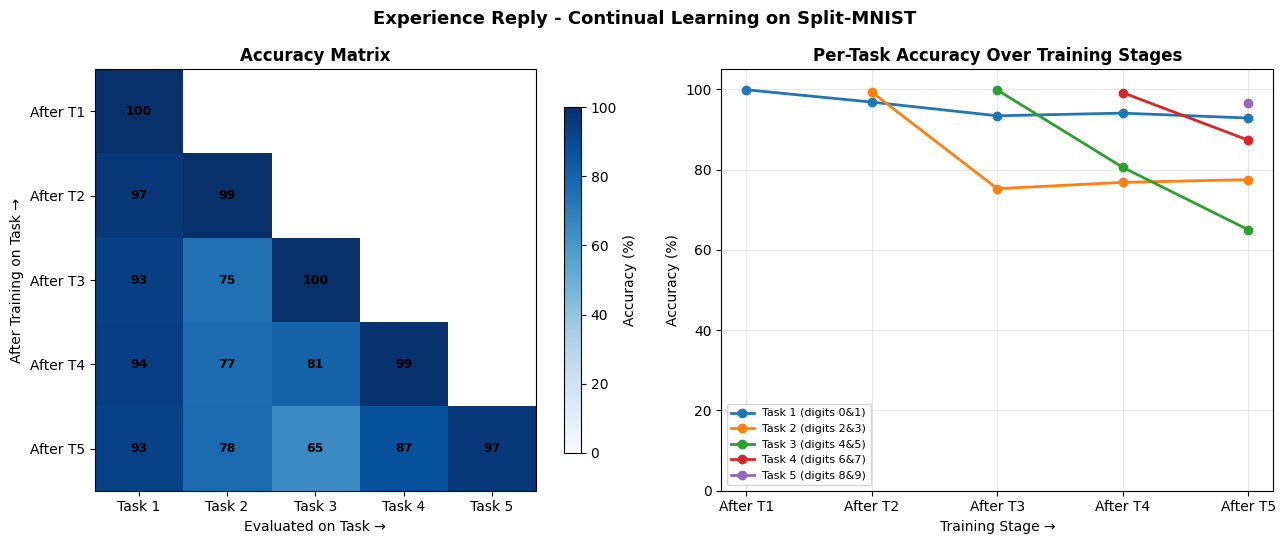


Figure saved → experience_reply_accuracy.png

Done! ✓


In [39]:
if __name__ == "__main__":
  print("Loading Split-MNIST...")
  task_loaders = build_split_mnist(data_root="./data", batch_size=128)

  acc_matrix = run_experience_replay(
      task_loaders,
      n_epochs=5,
      lr=1e-3,
      replay_buffer_size=500,
      replay_batch_size=64,
      samples_per_task=100,
      device=device
  )

  plot_accuracy(acc_matrix)
  print("\nDone! ✓")